# Secure-MaintAI — Model 01
## System Telemetry & Anomaly Detection — Real SMD Benchmark

### Objective

Model 01 is the first ML layer of Secure-MaintAI.

Its responsibility is:

> **Detect whether the current system telemetry is anomalous compared with the machine's learned normal behavior.**

It is an **anomaly-evidence layer**, not a diagnostic classifier and not a SOAR controller.

### Real dataset

This notebook uses the **Server Machine Dataset (SMD)**:

- 28 server machines
- 38 telemetry channels per machine
- training split used for model fitting
- test split with point-level anomaly labels
- multivariate server telemetry

Dataset/project reference:
https://github.com/NetManAIOps/OmniAnomaly

### Secure-MaintAI architecture

```text
Telemetry
   |
   v
Model 01
System Telemetry & Anomaly Detection
   |
   +--> anomaly score
   +--> threshold
   +--> anomaly flag
   +--> severity
   +--> evidence
   |
   v
Model 02
Technical Failure vs Cyber Attack
   |
   v
Risk Fusion / Policy / SOAR
```

**Important:** test labels are never used to fit the detector or choose the anomaly threshold.


## 1. Why SMD is the primary Model 01 benchmark

SMD is much closer to the telemetry problem described by Secure-MaintAI than a univariate benchmark.

The project report requires continuous infrastructure telemetry and anomaly detection over signals such as CPU, RAM and Disk I/O. Model 01 therefore needs a multivariate time-series benchmark rather than a single CloudWatch series.

This notebook evaluates all available SMD machines rather than selecting one convenient machine.


In [ ]:
# 2. Install dependencies
%pip -q install numpy pandas scikit-learn matplotlib seaborn joblib


In [1]:
# 3. Imports and reproducibility
from __future__ import annotations

import json

import datetime
import os
import re
import zipfile
from dataclasses import dataclass, asdict
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

SEED = 42
np.random.seed(SEED)

WORK_DIR = Path.cwd()
DATA_DIR = WORK_DIR / "data"
SMD_DIR = DATA_DIR / "ServerMachineDataset"
OUTPUT_DIR = WORK_DIR / "model_01_outputs"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR)
print("Expected SMD directory:", SMD_DIR)


Working directory: d:\workspace\2026_2027\FirstSemester\KKU\secure-maintai\ml
Expected SMD directory: d:\workspace\2026_2027\FirstSemester\KKU\secure-maintai\ml\data\ServerMachineDataset


## 2. Dataset preparation

Place the real `ServerMachineDataset.zip` under `data/`, or extract the repository layout into `data/ServerMachineDataset/`.

Expected structure:

```text
ServerMachineDataset/
├── train/
├── test/
└── test_label/
```

The loader below also searches recursively for the standard `train`, `test`, and `test_label` directories.


In [2]:
# 5. Automatically locate/extract the real SMD dataset
possible_zips = [
    DATA_DIR / "ServerMachineDataset.zip",      # primary location
    WORK_DIR / "ServerMachineDataset.zip",
    WORK_DIR / "ServerMachineDataset(1).zip",
    Path("/mnt/data/ServerMachineDataset.zip"),
    Path("/mnt/data/ServerMachineDataset(1).zip"),
]

zip_candidates = [p for p in possible_zips if p.exists()]

if zip_candidates and not SMD_DIR.exists():
    source_zip = zip_candidates[0]
    print("Extracting:", source_zip)
    with zipfile.ZipFile(source_zip, "r") as zf:
        zf.extractall(DATA_DIR)

# Search for directory containing train/test/test_label
if not (SMD_DIR / "train").exists():
    matches = []
    for p in DATA_DIR.rglob("train"):
        if p.is_dir() and (p.parent / "test").exists() and (p.parent / "test_label").exists():
            matches.append(p.parent)
    if matches:
        SMD_DIR = matches[0]

print("SMD root:", SMD_DIR)
print("Exists:", SMD_DIR.exists())

if not (SMD_DIR / "train").exists():
    raise FileNotFoundError(
        "SMD dataset not found. Put ServerMachineDataset.zip under data/ "
        "or extract the real SMD directory there."
    )


SMD root: d:\workspace\2026_2027\FirstSemester\KKU\secure-maintai\ml\data\ServerMachineDataset
Exists: True


In [3]:
# 6. SMD file inventory
train_files = sorted((SMD_DIR / "train").glob("*.txt"))
test_files = sorted((SMD_DIR / "test").glob("*.txt"))
label_files = sorted((SMD_DIR / "test_label").glob("*.txt"))

print("Train files :", len(train_files))
print("Test files  :", len(test_files))
print("Label files :", len(label_files))

print("\nFirst train files:")
for p in train_files[:10]:
    print(" ", p.name)

if not train_files or not test_files or not label_files:
    raise RuntimeError("SMD train/test/test_label files are incomplete.")


Train files : 28
Test files  : 28
Label files : 28

First train files:
  machine-1-1.txt
  machine-1-2.txt
  machine-1-3.txt
  machine-1-4.txt
  machine-1-5.txt
  machine-1-6.txt
  machine-1-7.txt
  machine-1-8.txt
  machine-2-1.txt
  machine-2-2.txt


In [4]:
# 7. Robust SMD loader
def read_matrix(path: Path) -> np.ndarray:
    return np.loadtxt(path, delimiter=",", dtype=np.float32)


def machine_id_from_path(path: Path) -> str:
    return path.stem


def build_machine_index() -> dict[str, dict[str, Path]]:
    train_map = {machine_id_from_path(p): p for p in train_files}
    test_map = {machine_id_from_path(p): p for p in test_files}
    label_map = {machine_id_from_path(p): p for p in label_files}

    ids = sorted(set(train_map) & set(test_map) & set(label_map))
    return {
        mid: {
            "train": train_map[mid],
            "test": test_map[mid],
            "label": label_map[mid],
        }
        for mid in ids
    }


MACHINES = build_machine_index()
print("Machines available for complete evaluation:", len(MACHINES))
print(list(MACHINES)[:10])


Machines available for complete evaluation: 28
['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5', 'machine-1-6', 'machine-1-7', 'machine-1-8', 'machine-2-1', 'machine-2-2']


## 3. Feature engineering

The detector uses:

### Raw telemetry
All 38 SMD channels.

### Causal temporal features
For each timestamp:

- first difference for every telemetry channel;
- absolute first-difference maximum;
- row mean and row standard deviation;
- multivariate delta L2 magnitude;
- exponentially weighted moving statistics.

All temporal features are causal: a timestamp only uses information available up to that timestamp.

No future test observations are used to construct features for a current test point.


In [5]:
# 9. Causal feature engineering
def temporal_features(
    train_raw: np.ndarray,
    test_raw: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:

    train_raw = np.asarray(train_raw, dtype=np.float32)
    test_raw = np.asarray(test_raw, dtype=np.float32)

    # Training features are computed only from training history.
    train_delta = np.diff(
        train_raw,
        axis=0,
        prepend=train_raw[[0]],
    )
    train_abs_delta = np.abs(train_delta)

    train_mean = train_raw.mean(axis=1)
    train_std = train_raw.std(axis=1)
    train_delta_l2 = np.sqrt(np.sum(train_delta * train_delta, axis=1))
    train_delta_max = train_abs_delta.max(axis=1)

    # Test features start with the final observed training state.
    combined = np.vstack([train_raw[-1:], test_raw])
    test_delta = np.diff(combined, axis=0)

    test_abs_delta = np.abs(test_delta)
    test_mean = test_raw.mean(axis=1)
    test_std = test_raw.std(axis=1)
    test_delta_l2 = np.sqrt(np.sum(test_delta * test_delta, axis=1))
    test_delta_max = test_abs_delta.max(axis=1)

    def ewma(values, alpha=0.2):
        out = np.empty(len(values), dtype=np.float32)
        if len(values) == 0:
            return out
        out[0] = values[0]
        for i in range(1, len(values)):
            out[i] = alpha * values[i] + (1 - alpha) * out[i - 1]
        return out

    train_ewma_mean = ewma(train_mean)
    train_ewma_std = ewma(train_std)
    train_ewma_delta = ewma(train_delta_l2)

    # For test EWMA, initialise from final training statistics.
    alpha = 0.2
    test_ewma_mean = np.empty(len(test_raw), dtype=np.float32)
    test_ewma_std = np.empty(len(test_raw), dtype=np.float32)
    test_ewma_delta = np.empty(len(test_raw), dtype=np.float32)

    prev_mean = float(train_ewma_mean[-1])
    prev_std = float(train_ewma_std[-1])
    prev_delta = float(train_ewma_delta[-1])

    for i in range(len(test_raw)):
        test_ewma_mean[i] = alpha * test_mean[i] + (1 - alpha) * prev_mean
        test_ewma_std[i] = alpha * test_std[i] + (1 - alpha) * prev_std
        test_ewma_delta[i] = alpha * test_delta_l2[i] + (1 - alpha) * prev_delta
        prev_mean = test_ewma_mean[i]
        prev_std = test_ewma_std[i]
        prev_delta = test_ewma_delta[i]

    train_temporal = np.column_stack([
        train_delta,
        train_mean,
        train_std,
        train_delta_l2,
        train_delta_max,
        train_ewma_mean,
        train_ewma_std,
        train_ewma_delta,
    ]).astype(np.float32)

    test_temporal = np.column_stack([
        test_delta,
        test_mean,
        test_std,
        test_delta_l2,
        test_delta_max,
        test_ewma_mean,
        test_ewma_std,
        test_ewma_delta,
    ]).astype(np.float32)

    X_train = np.hstack([train_raw, train_temporal]).astype(np.float32)
    X_test = np.hstack([test_raw, test_temporal]).astype(np.float32)

    return X_train, X_test


## 4. Primary detector — Isolation Forest

For each machine:

1. fit `RobustScaler` on training telemetry/features;
2. fit Isolation Forest only on the training split;
3. compute training anomaly scores;
4. select a machine-specific threshold from the training score distribution;
5. score the untouched test split.

The benchmark threshold is the **99th percentile of training anomaly scores**.

SMD test labels are used only for final evaluation.


In [6]:
# 11. Detector definition
@dataclass
class MachineResult:
    machine_id: str
    n_train: int
    n_test: int
    anomaly_points: int
    predicted_anomaly_points: int
    precision: float
    recall: float
    f1: float
    balanced_accuracy: float
    roc_auc: float
    average_precision: float
    event_recall: float
    false_positive_rate: float
    threshold_quantile: float


def anomaly_scores(model: IsolationForest, X: np.ndarray) -> np.ndarray:
    # Higher score = more anomalous.
    return -model.decision_function(X)


def event_level_recall(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Detect whether each contiguous true anomaly event has at least one hit.
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if y_true.sum() == 0:
        return float("nan")

    starts = np.where((y_true == 1) & np.r_[True, y_true[:-1] == 0])[0]
    ends = np.where((y_true == 1) & np.r_[y_true[1:] == 0, True])[0]

    detected = 0
    for start, end in zip(starts, ends):
        if y_pred[start:end + 1].any():
            detected += 1

    return detected / len(starts)


def point_fpr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    negatives = (y_true == 0)
    if negatives.sum() == 0:
        return float("nan")
    return float(((y_pred == 1) & negatives).sum() / negatives.sum())


In [7]:
# 12. Run full 28-machine benchmark
all_results = []
machine_artifacts = {}

N_ESTIMATORS = 150
MAX_SAMPLES = 2048
THRESHOLD_QUANTILE = 0.99

for machine_id, paths in MACHINES.items():
    train_raw = read_matrix(paths["train"])
    test_raw = read_matrix(paths["test"])
    y_test = read_matrix(paths["label"]).reshape(-1).astype(int)

    if len(test_raw) != len(y_test):
        raise ValueError(
            f"{machine_id}: test rows {len(test_raw)} != labels {len(y_test)}"
        )

    X_train, X_test = temporal_features(train_raw, test_raw)

    scaler = RobustScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    model = IsolationForest(
        n_estimators=N_ESTIMATORS,
        max_samples=min(MAX_SAMPLES, len(Xtr)),
        contamination="auto",
        random_state=SEED,
        n_jobs=-1,
    )
    model.fit(Xtr)

    train_scores = anomaly_scores(model, Xtr)
    test_scores = anomaly_scores(model, Xte)

    threshold = float(np.quantile(train_scores, THRESHOLD_QUANTILE))
    y_pred = (test_scores >= threshold).astype(int)

    result = MachineResult(
        machine_id=machine_id,
        n_train=len(train_raw),
        n_test=len(test_raw),
        anomaly_points=int(y_test.sum()),
        predicted_anomaly_points=int(y_pred.sum()),
        precision=float(precision_score(y_test, y_pred, zero_division=0)),
        recall=float(recall_score(y_test, y_pred, zero_division=0)),
        f1=float(f1_score(y_test, y_pred, zero_division=0)),
        balanced_accuracy=float(balanced_accuracy_score(y_test, y_pred)),
        roc_auc=float(roc_auc_score(y_test, test_scores)),
        average_precision=float(average_precision_score(y_test, test_scores)),
        event_recall=float(event_level_recall(y_test, y_pred)),
        false_positive_rate=float(point_fpr(y_test, y_pred)),
        threshold_quantile=THRESHOLD_QUANTILE,
    )

    all_results.append(asdict(result))

    machine_artifacts[machine_id] = {
        "scaler": scaler,
        "model": model,
        "threshold": threshold,
        "train_feature_count": Xtr.shape[1],
        # C2 / M2: versioning + EWMA tail for single-observation inference
        "model_version": "1.0.0",
        "feature_version": "1.0.0",
        "training_date": datetime.datetime.utcnow().isoformat() + "Z",
        "ewma_tail": {
            "last_raw": train_raw[-1].tolist(),
        },
    }

    print(
        f"{machine_id}: "
        f"ROC-AUC={result.roc_auc:.4f}, "
        f"F1={result.f1:.4f}, "
        f"EventRecall={result.event_recall:.4f}"
    )

results_df = pd.DataFrame(all_results)

print("\nMachines evaluated:", len(results_df))
display(results_df.round(4))


C:\Users\MC\AppData\Local\Temp\ipykernel_552\4238280817.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


machine-1-1: ROC-AUC=0.8794, F1=0.4203, EventRecall=1.0000


C:\Users\MC\AppData\Local\Temp\ipykernel_552\4238280817.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


machine-1-2: ROC-AUC=0.8802, F1=0.2142, EventRecall=0.9000


C:\Users\MC\AppData\Local\Temp\ipykernel_552\4238280817.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


...

machine-3-7: ROC-AUC=0.7023, F1=0.2165, EventRecall=1.0000


C:\Users\MC\AppData\Local\Temp\ipykernel_552\4238280817.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


machine-3-8: ROC-AUC=0.9182, F1=0.4162, EventRecall=1.0000
machine-3-9: ROC-AUC=0.7072, F1=0.0349, EventRecall=1.0000

Machines evaluated: 28


C:\Users\MC\AppData\Local\Temp\ipykernel_552\4238280817.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


,machine_id,n_train,n_test,anomaly_points,predicted_anomaly_points,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,event_recall,false_positive_rate,threshold_quantile
0,machine-1-1,28479,28479,2694,4106,0.3480,0.5304,0.4203,0.7133,0.8794,0.4222,1.0000,0.1038,0.99
1,machine-1-2,23694,23694,542,289,0.3080,0.1642,0.2142,0.5778,0.8802,0.2390,0.9000,0.0086,0.99
2,machine-1-3,23702,23703,817,443,0.4898,0.2656,0.3444,0.6279,0.7823,0.3265,1.0000,0.0099,0.99
3,machine-1-4,23706,23707,720,422,0.4668,0.2736,0.3450,0.6319,0.8326,0.3206,1.0000,0.0098,0.99
4,machine-1-5,23705,23706,100,789,0.0722,0.5700,0.1282,0.7695,0.8656,0.3164,1.0000,0.0310,0.99
5,machine-1-6,23688,23689,3708,14879,0.2327,0.9337,0.3725,0.6811,0.8826,0.6781,0.9667,0.5714,0.99
6,machine-1-7,23697,23697,2398,178,0.7360,0.0546,0.1017,0.5262,0.7681,0.3075,0.7692,0.0022,0.99
7,machine-1-8,23698,23699,763,868,0.1797,0.2045,0.1913,0.5867,0.6343,0.1731,0.6500,0.0310,0.99
8,machine-2-1,23693,23694,1170,293,0.3174,0.0795,0.1271,0.5353,0.6988,0.1748,0.9231,0.0089,0.99
9,machine-2-2,23699,23700,2833,742,0.2695,0.0706,0.1119,0.5223,0.6517,0.2001,0.9091,0.0260,0.99


In [8]:
# 13. Macro benchmark results
macro_metrics = {
    "Precision": results_df["precision"].mean(),
    "Recall": results_df["recall"].mean(),
    "F1": results_df["f1"].mean(),
    "Balanced Accuracy": results_df["balanced_accuracy"].mean(),
    "ROC-AUC": results_df["roc_auc"].mean(),
    "Average Precision": results_df["average_precision"].mean(),
    "Event Recall": results_df["event_recall"].mean(),
    "False Positive Rate": results_df["false_positive_rate"].mean(),
}

macro_df = pd.DataFrame(
    {"metric": list(macro_metrics.keys()), "value": list(macro_metrics.values())}
)

display(
    macro_df.assign(
        percentage=lambda d: (d["value"] * 100).round(2)
    )[["metric", "percentage"]]
)

print("\nMean ± std:")
for metric, value in macro_metrics.items():
    std = results_df[
        {
            "Precision": "precision",
            "Recall": "recall",
            "F1": "f1",
            "Balanced Accuracy": "balanced_accuracy",
            "ROC-AUC": "roc_auc",
            "Average Precision": "average_precision",
            "Event Recall": "event_recall",
            "False Positive Rate": "false_positive_rate",
        }[metric]
    ].std()
    print(f"{metric:20s}: {value:.4f} ± {std:.4f}")


,metric,percentage
0,Precision,29.10
1,Recall,40.50
2,F1,25.31
3,Balanced Accuracy,66.32
4,ROC-AUC,81.28
5,Average Precision,34.93
6,Event Recall,91.38
7,False Positive Rate,7.87



Mean ± std:
Precision           : 0.2910 ± 0.1830
Recall              : 0.4050 ± 0.2806
F1                  : 0.2531 ± 0.1721
Balanced Accuracy   : 0.6632 ± 0.1203
ROC-AUC             : 0.8128 ± 0.1031
Average Precision   : 0.3493 ± 0.2203
Event Recall        : 0.9138 ± 0.1475
False Positive Rate : 0.0787 ± 0.1334


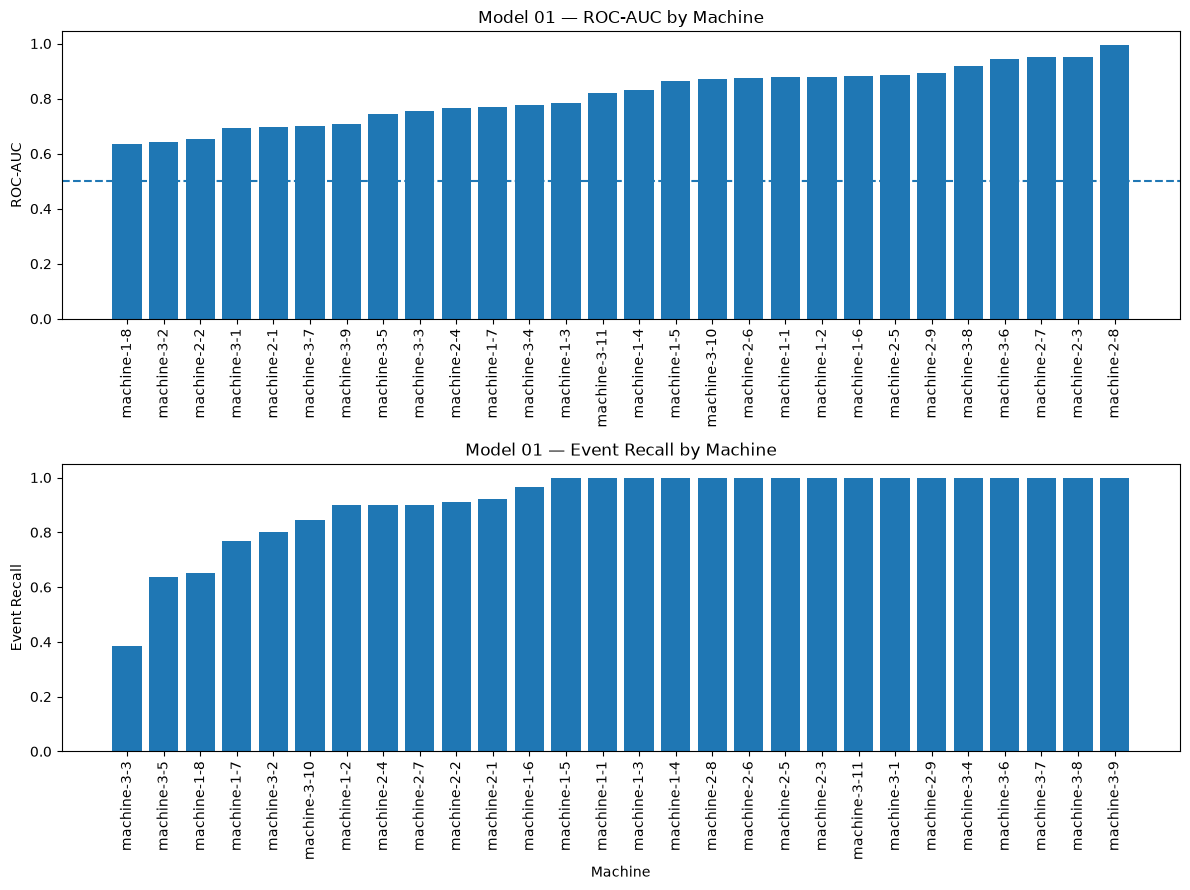

In [9]:
# 14. Visualise per-machine ROC-AUC and Event Recall
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

plot_df = results_df.sort_values("roc_auc")

axes[0].bar(plot_df["machine_id"], plot_df["roc_auc"])
axes[0].axhline(0.5, linestyle="--")
axes[0].set_title("Model 01 — ROC-AUC by Machine")
axes[0].set_ylabel("ROC-AUC")
axes[0].tick_params(axis="x", rotation=90)

plot_df2 = results_df.sort_values("event_recall")

axes[1].bar(plot_df2["machine_id"], plot_df2["event_recall"])
axes[1].set_title("Model 01 — Event Recall by Machine")
axes[1].set_ylabel("Event Recall")
axes[1].set_xlabel("Machine")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## 5. Secondary detector — PCA reconstruction error

PCA is retained as a secondary benchmark/corroboration detector.

It is **not** used to replace the primary Isolation Forest in this notebook.

The purpose is to quantify whether a second unsupervised detector gives complementary evidence for later Risk Fusion.


In [10]:
# 16. PCA comparison on the same real SMD data
pca_results = []

for machine_id, paths in MACHINES.items():
    train_raw = read_matrix(paths["train"])
    test_raw = read_matrix(paths["test"])
    y_test = read_matrix(paths["label"]).reshape(-1).astype(int)

    X_train, X_test = temporal_features(train_raw, test_raw)

    scaler = RobustScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    pca = PCA(n_components=0.95, svd_solver="full", random_state=SEED)
    Ztr = pca.fit_transform(Xtr)
    Zte = pca.transform(Xte)

    recon_train = pca.inverse_transform(Ztr)
    recon_test = pca.inverse_transform(Zte)

    train_error = np.mean((Xtr - recon_train) ** 2, axis=1)
    test_error = np.mean((Xte - recon_test) ** 2, axis=1)

    threshold = float(np.quantile(train_error, THRESHOLD_QUANTILE))
    y_pred = (test_error >= threshold).astype(int)

    pca_results.append({
        "machine_id": machine_id,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, test_error),
        "average_precision": average_precision_score(y_test, test_error),
        "event_recall": event_level_recall(y_test, y_pred),
        "false_positive_rate": point_fpr(y_test, y_pred),
    })

pca_df = pd.DataFrame(pca_results)

comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "Average Precision",
        "Event Recall",
        "False Positive Rate",
    ],
    "Isolation Forest": [
        results_df["precision"].mean(),
        results_df["recall"].mean(),
        results_df["f1"].mean(),
        results_df["balanced_accuracy"].mean(),
        results_df["roc_auc"].mean(),
        results_df["average_precision"].mean(),
        results_df["event_recall"].mean(),
        results_df["false_positive_rate"].mean(),
    ],
    "PCA": [
        pca_df["precision"].mean(),
        pca_df["recall"].mean(),
        pca_df["f1"].mean(),
        pca_df["balanced_accuracy"].mean(),
        pca_df["roc_auc"].mean(),
        pca_df["average_precision"].mean(),
        pca_df["event_recall"].mean(),
        pca_df["false_positive_rate"].mean(),
    ],
})

display(comparison.assign(
    **{
        "Isolation Forest (%)": comparison["Isolation Forest"] * 100,
        "PCA (%)": comparison["PCA"] * 100,
    }
)[["Metric", "Isolation Forest (%)", "PCA (%)"]].round(2))


,Metric,Isolation Forest (%),PCA (%)
0,Precision,29.10,33.32
1,Recall,40.50,46.69
2,F1,25.31,26.41
3,Balanced Accuracy,66.32,67.88
4,ROC-AUC,81.28,80.46
5,Average Precision,34.93,41.19
6,Event Recall,91.38,91.55
7,False Positive Rate,7.87,10.94


## 6. Selecting the primary detector

The selection rule is operational, not just based on one metric:

- prefer strong ROC-AUC;
- prefer lower false-positive rate;
- preserve high event-level recall;
- keep the detector suitable for downstream anomaly evidence.

Isolation Forest remains the primary detector when it provides the strongest overall combination of ROC-AUC and false-positive control.

PCA remains available as corroborating evidence.


In [11]:
# 18. Primary detector decision
if (
    results_df["roc_auc"].mean() >= pca_df["roc_auc"].mean()
    and results_df["false_positive_rate"].mean() <= pca_df["false_positive_rate"].mean()
):
    primary_detector = "Isolation Forest"
else:
    # Keep the project design explicit even when benchmark trade-offs change.
    primary_detector = "Isolation Forest (primary), PCA (corroborating)"

print("Primary Model 01 detector:", primary_detector)


Primary Model 01 detector: Isolation Forest


In [12]:
# 19. Save trained machine artifacts and benchmark results
for machine_id, artifact in machine_artifacts.items():
    joblib.dump(
        artifact,
        MODEL_DIR / f"{machine_id}.joblib"
    )

benchmark = {
    "project": "Secure-MaintAI",
    "model_name": "model_01_isolation_forest",
    "model_version": "1.0.0",
    "feature_version": "1.0.0",
    "training_date": datetime.datetime.utcnow().isoformat() + "Z",
    "model": "Model 01 — System Telemetry & Anomaly Detection",
    "dataset": "Server Machine Dataset (SMD)",
    "machines_evaluated": int(len(results_df)),
    "detector": "Isolation Forest",
    "configuration": {
        "n_estimators": N_ESTIMATORS,
        "max_samples": MAX_SAMPLES,
        "scaler": "RobustScaler",
        "threshold_quantile": THRESHOLD_QUANTILE,
        "seed": SEED,
        "features": "38 raw channels + causal temporal features",
    },
    "macro_results": macro_metrics,
    "secondary_detector": "PCA reconstruction error",
    "safety_boundary": (
        "Anomaly evidence only. No diagnosis and no direct SOAR action."
    ),
}

(OUTPUT_DIR / "model_01_smd_real_benchmark.json").write_text(
    json.dumps(benchmark, indent=2),
    encoding="utf-8"
)

results_df.to_csv(
    OUTPUT_DIR / "model_01_smd_per_machine_results.csv",
    index=False
)

comparison.to_csv(
    OUTPUT_DIR / "model_01_smd_detector_comparison.csv",
    index=False
)

print("Saved benchmark artifacts to:", OUTPUT_DIR)


Saved benchmark artifacts to: d:\workspace\2026_2027\FirstSemester\KKU\secure-maintai\ml\model_01_outputs


C:\Users\MC\AppData\Local\Temp\ipykernel_552\3436895488.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.datetime.utcnow().isoformat() + "Z",


In [14]:
# 20. Production-style inference for one machine
def load_machine_detector(machine_id: str):
    artifact_path = MODEL_DIR / f"{machine_id}.joblib"
    artifact = joblib.load(artifact_path)

    return artifact


# M3: severity bands — score-to-threshold ratio.
# These are operational defaults; override via SEVERITY_BANDS config dict.
SEVERITY_BANDS = {
    "critical": 1.50,
    "high": 1.20,
    "medium": 1.00,
}


def severity(score: float, threshold: float, bands: dict = SEVERITY_BANDS) -> str:
    """Return severity label based on score/threshold ratio.

    Args:
        score: raw anomaly score (higher = more anomalous).
        threshold: machine-specific threshold from training.
        bands: dict mapping label -> minimum ratio (descending).
    """
    ratio = score / max(threshold, 1e-12)
    if ratio >= bands["critical"]:
        return "critical"
    if ratio >= bands["high"]:
        return "high"
    if ratio >= bands["medium"]:
        return "medium"
    return "normal"


def infer_latest(machine_id: str, history_raw: np.ndarray, current_raw: np.ndarray) -> dict:
    artifact = load_machine_detector(machine_id)

    _, current_features = temporal_features(
        np.asarray(history_raw, dtype=np.float32),
        np.asarray(current_raw, dtype=np.float32).reshape(1, -1),
    )

    # M1: guard against preprocessing/feature-count mismatch
    expected_fc = artifact["train_feature_count"]
    actual_fc = current_features.shape[1]
    if actual_fc != expected_fc:
        raise ValueError(
            f"Feature count mismatch for {machine_id}: "
            f"expected {expected_fc}, got {actual_fc}. "
            "Re-train the model with the current preprocessing pipeline."
        )

    X = artifact["scaler"].transform(current_features)
    score = float(anomaly_scores(artifact["model"], X)[0])
    threshold = float(artifact["threshold"])

    return {
        "machine_id": machine_id,
        "anomaly_score": score,
        "threshold": threshold,
        "raw_flag": bool(score >= threshold),
        "severity": severity(score, threshold),
        "evidence": {
            "threshold_margin": score - threshold,
            "score_ratio": score / max(threshold, 1e-12),
        },
    }

print("Production inference contract ready.")


Production inference contract ready.


## 7. Scientific interpretation

### What this benchmark proves

It demonstrates how Model 01 behaves on a real multivariate server-telemetry benchmark under a train-only unsupervised learning setup.

### What it does not prove

It does **not** prove that identical performance will occur on Secure-MaintAI's university workstations.

Before deployment, the project should collect representative university telemetry and perform site-specific calibration.

### Model boundary

Model 01 answers:

> **Is this telemetry anomalous?**

It does not answer:

> **Why is it anomalous?**

That second question belongs to **Model 02 — Technical Failure vs Cyber Attack**.

Therefore the final ML chain remains:

```text
SMD / University Telemetry
        |
        v
Model 01
Anomaly Evidence
        |
        v
Model 02
Technical vs Cyber
        |
        v
Risk Fusion
        |
        v
Policy + IdP Role
        |
        v
SOAR
```
